# Environment test

Run each cell to verify your data science environment is set up correctly. All imports should succeed without errors.

In [6]:
import sys
print(f"Python {sys.version}")
assert sys.version_info[:2] == (3, 12), f"Expected Python 3.12, got {sys.version}"
print("Python version: OK")

Python 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
Python version: OK


## Core data science packages

In [7]:
import numpy as np
import pandas as pd
import scipy

print(f"numpy  {np.__version__}")
print(f"pandas {pd.__version__}")
print(f"scipy  {scipy.__version__}")

numpy  1.26.4
pandas 2.2.3
scipy  1.17.1


In [8]:
import sklearn
import xgboost as xgb
import statsmodels

print(f"scikit-learn {sklearn.__version__}")
print(f"xgboost      {xgb.__version__}")
print(f"statsmodels  {statsmodels.__version__}")

scikit-learn 1.9.0
xgboost      3.3.0
statsmodels  0.14.6


## Visualization packages

In [9]:
import matplotlib
import seaborn as sns
import plotly

print(f"matplotlib {matplotlib.__version__}")
print(f"seaborn    {sns.__version__}")
print(f"plotly     {plotly.__version__}")

matplotlib 3.11.0
seaborn    0.13.2
plotly     6.8.0


## Hyperparameter optimization

In [10]:
import optuna

print(f"optuna {optuna.__version__}")

optuna 4.9.0


## Quick smoke test

Create a small dataset, train an XGBoost model, and plot the results to verify the full stack is working end-to-end.

Test accuracy: 0.9561


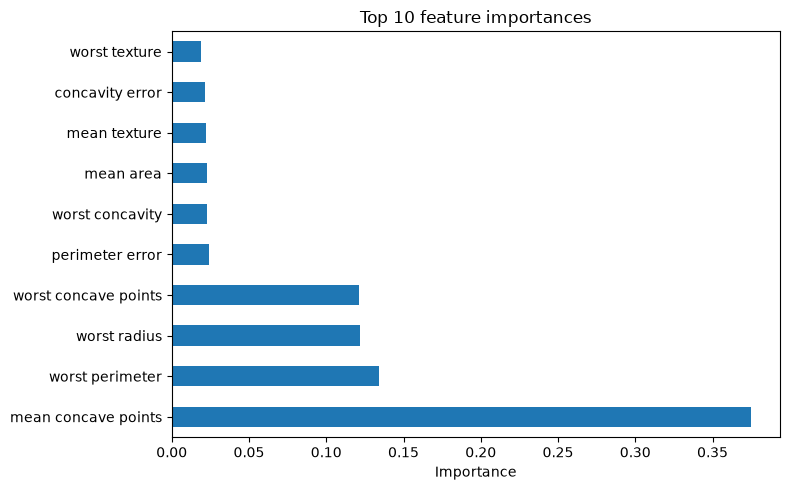

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load sample data
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# Train XGBoost model
model = xgb.XGBClassifier(n_estimators=50, random_state=42, eval_metric="logloss")
model.fit(X_train, y_train)

# Evaluate
acc = accuracy_score(y_test, model.predict(X_test))
print(f"Test accuracy: {acc:.4f}")

# Plot feature importances
fig, ax = plt.subplots(figsize=(8, 5))
feat_imp = pd.Series(model.feature_importances_, index=data.feature_names).nlargest(10)
feat_imp.plot(kind="barh", ax=ax)
ax.set_title("Top 10 feature importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## GPU acceleration (NVIDIA only)

The cell below checks for CuPy, which provides GPU-accelerated NumPy-compatible arrays. If you are using the **DataScience NVIDIA** container, this should succeed. On CPU or Mac containers, it will print a message and skip gracefully.

In [12]:
try:
    import cupy as cp
    a = cp.array([1, 2, 3])
    b = cp.array([4, 5, 6])
    print(f"cupy {cp.__version__} -- GPU detected: {cp.cuda.runtime.getDeviceCount()} device(s)")
    print(f"cupy dot product: {cp.dot(a, b)}")
except ImportError:
    print("cupy not available -- this is expected on CPU and Mac containers.")
except Exception as e:
    print(f"cupy import succeeded but GPU not available: {e}")

cupy 13.6.0 -- GPU detected: 1 device(s)
cupy dot product: 32
